In [30]:
import numpy as np
from sklearn.linear_model import OrthogonalMatchingPursuit
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.linalg import toeplitz

In [2]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'

In [3]:
u = np.genfromtxt("contrast.txt")
u

array([[0.      , 0.      , 0.      , ..., 0.168482, 0.168466, 0.168449],
       [0.      , 0.      , 0.      , ..., 0.168535, 0.168519, 0.168502],
       [0.      , 0.      , 0.      , ..., 0.168588, 0.168571, 0.168555],
       ...,
       [0.      , 0.      , 0.      , ..., 0.189189, 0.189185, 0.18918 ],
       [0.      , 0.      , 0.      , ..., 0.189203, 0.189199, 0.189195],
       [0.      , 0.      , 0.      , ..., 0.189211, 0.189206, 0.189202]])

In [4]:
u.shape

(1001, 30001)

In [6]:
input = u[0,:]
output = u[-1, :]

In [7]:
input.size

30001

In [8]:
t = np.linspace(0, 10, input.size)

In [82]:
syst = 0.32
arr_end_syst = np.arange(0, 10) + syst
arr_end_syst

array([0.32, 1.32, 2.32, 3.32, 4.32, 5.32, 6.32, 7.32, 8.32, 9.32])

In [83]:
input_CT_MPI = np.zeros_like(arr_end_syst)
output_CT_MPI = np.zeros_like(arr_end_syst)
for i, value in enumerate(arr_end_syst):
    input_CT_MPI[i] = input[np.isclose(t, value)]
    output_CT_MPI[i] = output[np.isclose(t, value)]

print(input_CT_MPI)

[0.021815 0.22514  0.421827 0.523947 0.538061 0.494926 0.423646 0.344702
 0.270098 0.20557 ]


/var/folders/pd/rks0rhrj499g669rkntv95y40000gn/T/ipykernel_60312/1285850796.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  input_CT_MPI[i] = input[np.isclose(t, value)]
/var/folders/pd/rks0rhrj499g669rkntv95y40000gn/T/ipykernel_60312/1285850796.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  output_CT_MPI[i] = output[np.isclose(t, value)]


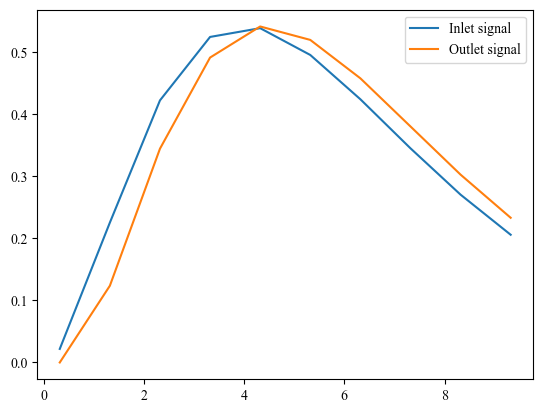

In [84]:
plt.plot(arr_end_syst, input_CT_MPI, label="Inlet signal")
plt.plot(arr_end_syst, output_CT_MPI, label="Outlet signal")
plt.legend()
plt.show()

In [85]:
interp_length = 1000
interp_input = interp1d(arr_end_syst, input_CT_MPI, kind='cubic')
interp_output = interp1d(arr_end_syst, output_CT_MPI, kind='cubic')
time_points_sampled = np.linspace(arr_end_syst[0], arr_end_syst[-1], interp_length)
input_function = interp_input(time_points_sampled)
output_function = interp_output(time_points_sampled)


0.0
inf


/var/folders/pd/rks0rhrj499g669rkntv95y40000gn/T/ipykernel_60312/82274646.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  v_estimated_omp = 10 / estimated_delay


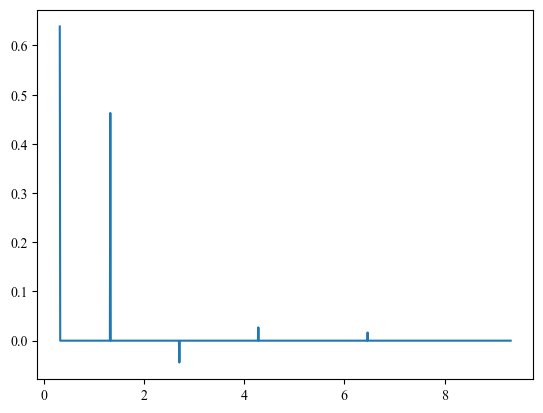

In [87]:
# creating the A matrix based on the input function using toeplitz structure
A = toeplitz(input_function, np.zeros(len(input_function)))

# Using Orthogonal Matching Pursuit (OMP) for recovering the actual input and output functions assuming sparsity
omp = OrthogonalMatchingPursuit(n_nonzero_coefs=5)
omp.fit(A, output_function)
x_sol_omp = omp.coef_
plt.figure()
plt.plot(time_points_sampled, x_sol_omp)
# Estimating velocity from the system response
delay_indices = np.argmax(x_sol_omp)  # index of maximum response
estimated_delay = time_points_sampled[delay_indices] - arr_end_syst[0]
print(estimated_delay)
v_estimated_omp = 10 / estimated_delay

print(v_estimated_omp)

In [88]:
arr_multiphase = np.array([1., 3.32, 4., 5.9, 6.8])
input_CT_MPI = np.zeros_like(arr_multiphase)
output_CT_MPI = np.zeros_like(arr_multiphase)
time_multiphase = np.zeros_like(arr_multiphase)
for i, value in enumerate(arr_multiphase):
    input_CT_MPI[i] = input[np.isclose(t, value)]
    output_CT_MPI[i] = output[np.isclose(t, value)]
    time_multiphase[i] = t[np.isclose(t, value)]

print(input_CT_MPI)
print(output_CT_MPI)
print(time_multiphase)

[0.151633 0.523947 0.541341 0.455486 0.385795]
[0.068092 0.490758 0.535785 0.478462 0.407573]
[1.   3.32 4.   5.9  6.8 ]


/var/folders/pd/rks0rhrj499g669rkntv95y40000gn/T/ipykernel_60312/896556952.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  input_CT_MPI[i] = input[np.isclose(t, value)]
/var/folders/pd/rks0rhrj499g669rkntv95y40000gn/T/ipykernel_60312/896556952.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  output_CT_MPI[i] = output[np.isclose(t, value)]
/var/folders/pd/rks0rhrj499g669rkntv95y40000gn/T/ipykernel_60312/896556952.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.2

0.3831831831831831
26.097178683385586


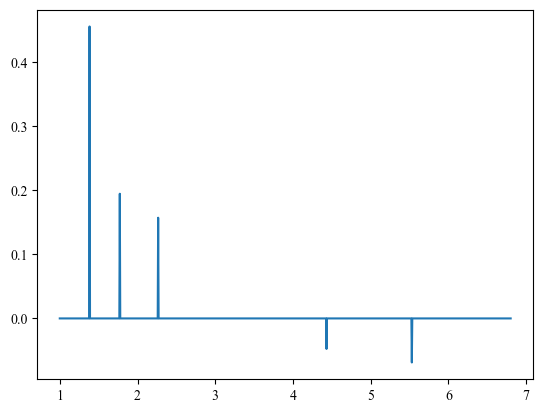

In [89]:
interp_length = 1000
interp_input = interp1d(arr_multiphase, input_CT_MPI, kind='cubic')
interp_output = interp1d(arr_multiphase, output_CT_MPI, kind='cubic')
time_points_sampled = np.linspace(time_multiphase[0], time_multiphase[-1], interp_length)
input_function = interp_input(time_points_sampled)
output_function = interp_output(time_points_sampled)


# creating the A matrix based on the input function using toeplitz structure
A = toeplitz(input_function, np.zeros(len(input_function)))

# Using Orthogonal Matching Pursuit (OMP) for recovering the actual input and output functions assuming sparsity
omp = OrthogonalMatchingPursuit(n_nonzero_coefs=5)
omp.fit(A, output_function)
x_sol_omp = omp.coef_
plt.figure()
plt.plot(time_points_sampled, x_sol_omp)
# Estimating velocity from the system response
indices = np.argsort(x_sol_omp)  # index of maximum response
delay_indices = indices[-1]
estimated_delay = time_points_sampled[delay_indices] - time_multiphase[0]
print(estimated_delay)
v_estimated_omp = 10 / estimated_delay

print(v_estimated_omp)